In [2]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine
import os
import datetime

In [3]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [4]:
query_min = "SELECT * FROM gold.active_1min"
query_30 = "SELECT * FROM gold.active_30min"
query_hr = "SELECT * FROM gold.active_1hr"
query_day = "SELECT * FROM gold.active_daily"

In [5]:
df_min = pd.read_sql(query_min,engine)
df_30 = pd.read_sql(query_30,engine)
df_hr = pd.read_sql(query_hr,engine)
df_day = pd.read_sql(query_day,engine)

In [6]:
df_min.info()
df_30.info()
df_hr.info()
df_day.info()

<class 'pandas.DataFrame'>
RangeIndex: 98297 entries, 0 to 98296
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   contract  98297 non-null  str    
 1   bar_date  98297 non-null  object 
 2   bar_time  98297 non-null  object 
 3   high      98297 non-null  float64
 4   open      98297 non-null  float64
 5   close     98297 non-null  float64
 6   low       98297 non-null  float64
 7   volume    98297 non-null  float64
dtypes: float64(5), object(2), str(1)
memory usage: 6.0+ MB
<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   contract        3282 non-null   str    
 1   bar_date        3282 non-null   object 
 2   bar_time        3282 non-null   object 
 3   high            3282 non-null   float64
 4   open            3282 non-null   float64
 5   close           3282 non-null   float6

Daily Volume Analysis

In [7]:
print(df_day['total_volume'].describe())
print("Median: ",df_day['total_volume'].median())
print("Std Dev: ",df_day['total_volume'].std())
print("IQR:", df_day['total_volume'].quantile(0.75) - df_day['total_volume'].quantile(0.25))

count       239.000000
mean      63806.564854
std       42292.486685
min        1101.000000
25%       41220.500000
50%       50924.000000
75%       75340.500000
max      369341.000000
Name: total_volume, dtype: float64
Median:  50924.0
Std Dev:  42292.486685423726
IQR: 34120.0


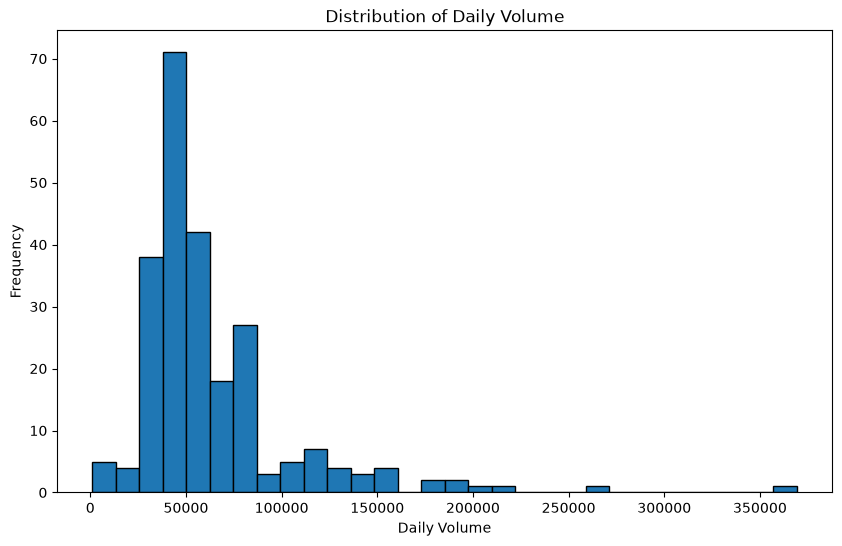

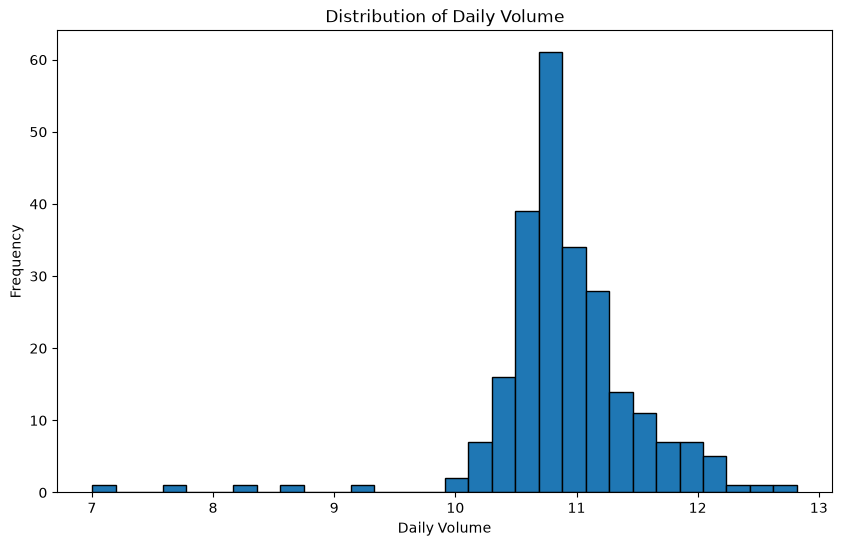

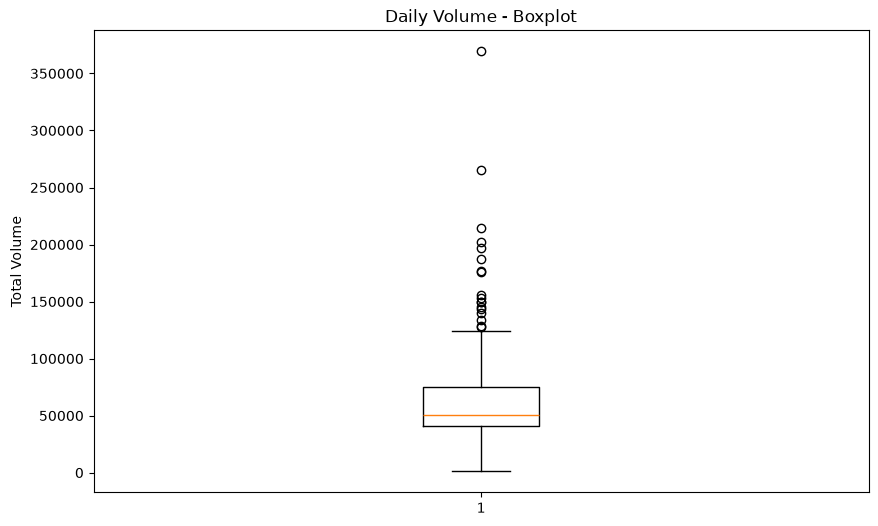

In [9]:
plt.figure(figsize=(10,6))
plt.hist(df_day['total_volume'],bins=30,edgecolor='black')
plt.xlabel('Daily Volume')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Volume')
plt.show()

df_day['log_volume']=np.log(df_day['total_volume'])
plt.figure(figsize=(10,6))
plt.hist(df_day['log_volume'],bins=30,edgecolor='black')
plt.xlabel('Daily Volume')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Volume')
plt.show()

plt.figure(figsize=(10,6))
plt.boxplot(df_day['total_volume'])
plt.ylabel('Total Volume')
plt.title('Daily Volume - Boxplot')
plt.show()

Hour Volume Analysis

In [12]:
hr_agg = df_hr.groupby('bar_time')['total_volume'].agg(['mean','median','std'])
df_hr['q1'] =df_hr.groupby('bar_time')['total_volume'].transform(lambda t: t.quantile(.25))
df_hr['q3'] =df_hr.groupby('bar_time')['total_volume'].transform(lambda t: t.quantile(.75))
df_hr_IQR = df_hr[(df_hr['total_volume']>=df_hr['q1'])&(df_hr['total_volume']<=df_hr['q3'])]
hr_agg_IQR = df_hr_IQR.groupby('bar_time')['total_volume'].agg(['mean','median','std'])

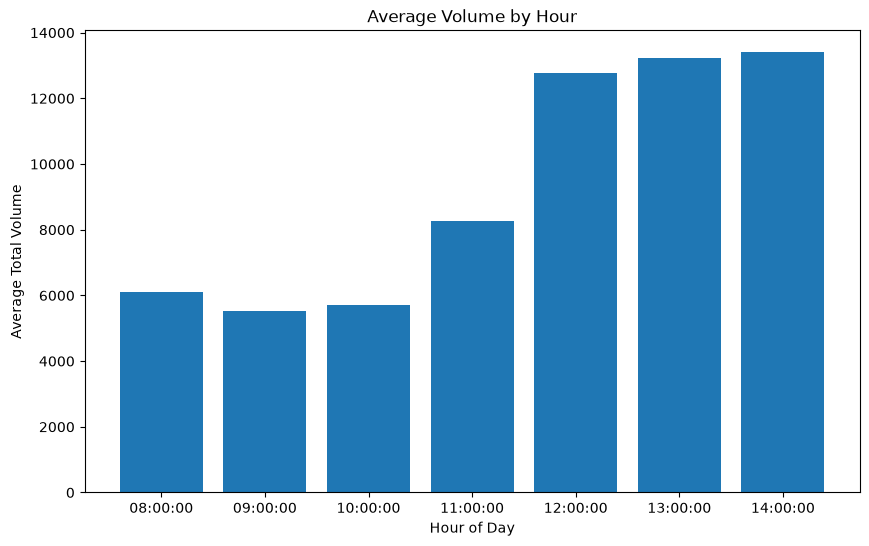

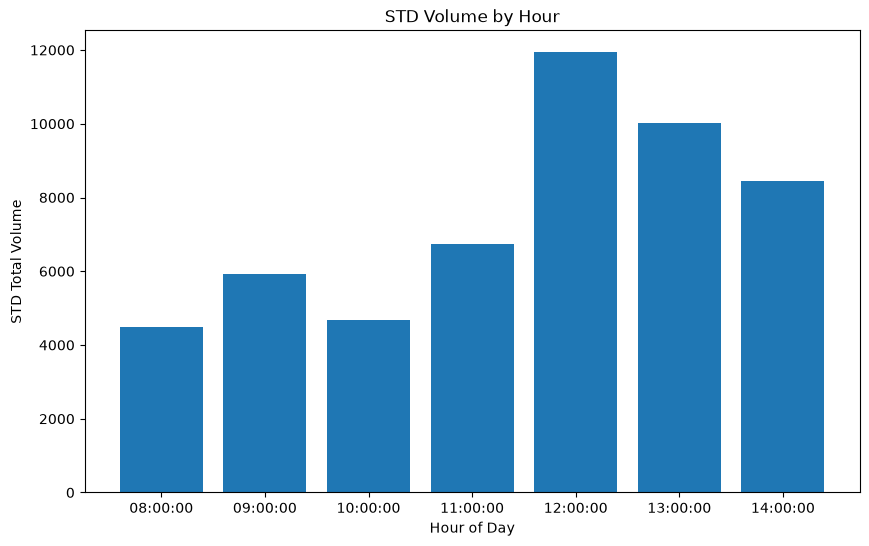

In [13]:
plt.figure(figsize=(10,6))
plt.bar(hr_agg.index.astype(str), hr_agg['mean'])
plt.xlabel('Hour of Day')
plt.ylabel('Average Total Volume')
plt.title('Average Volume by Hour')
plt.show()

plt.figure(figsize=(10,6))
plt.bar(hr_agg.index.astype(str), hr_agg['std'])
plt.xlabel('Hour of Day')
plt.ylabel('STD Total Volume')
plt.title('STD Volume by Hour')
plt.show()

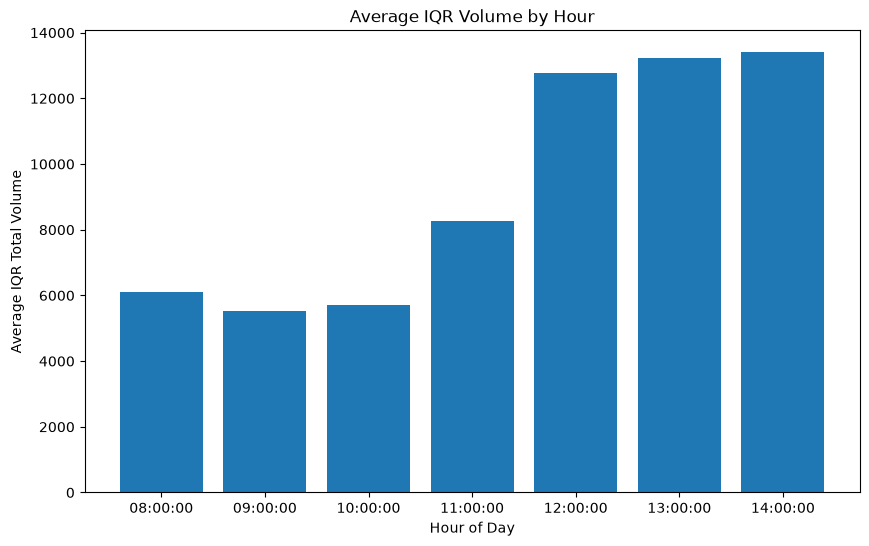

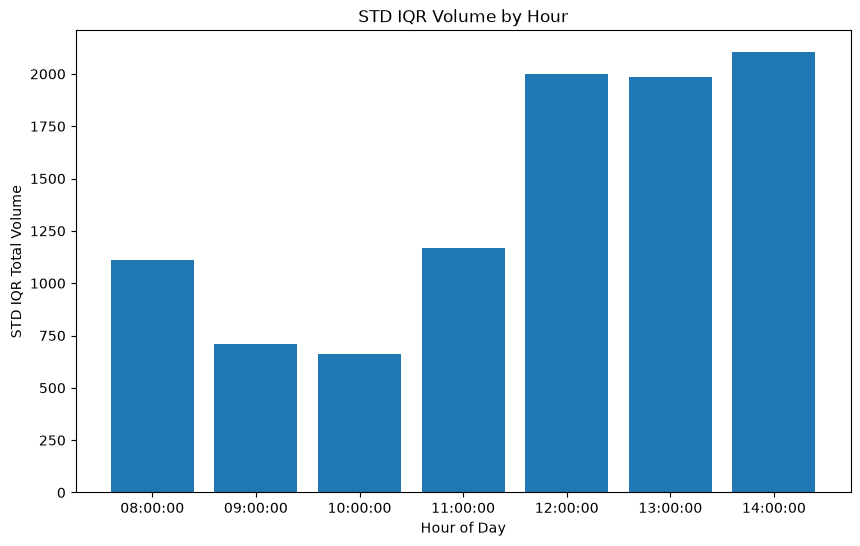

In [16]:
plt.figure(figsize=(10,6))
plt.bar(hr_agg_IQR.index.astype(str), hr_agg['mean'])
plt.xlabel('Hour of Day')
plt.ylabel('Average IQR Total Volume')
plt.title('Average IQR Volume by Hour')
plt.show()

plt.figure(figsize=(10,6))
plt.bar(hr_agg_IQR.index.astype(str), hr_agg_IQR['std'])
plt.xlabel('Hour of Day')
plt.ylabel('STD IQR Total Volume')
plt.title('STD IQR Volume by Hour')
plt.show()

30 Min Analysis

In [25]:
agg_30 = df_30.groupby('bar_time')['total_volume'].agg(['mean','median','std'])
df_30['q1'] =df_30.groupby('bar_time')['total_volume'].transform(lambda t: t.quantile(.25))
df_30['q3'] =df_30.groupby('bar_time')['total_volume'].transform(lambda t: t.quantile(.75))
df_30_IQR = df_30[(df_30['total_volume']>=df_30['q1'])&(df_30['total_volume']<=df_30['q3'])]
agg_30_IQR = df_30_IQR.groupby('bar_time')['total_volume'].agg(['mean','median','std'])

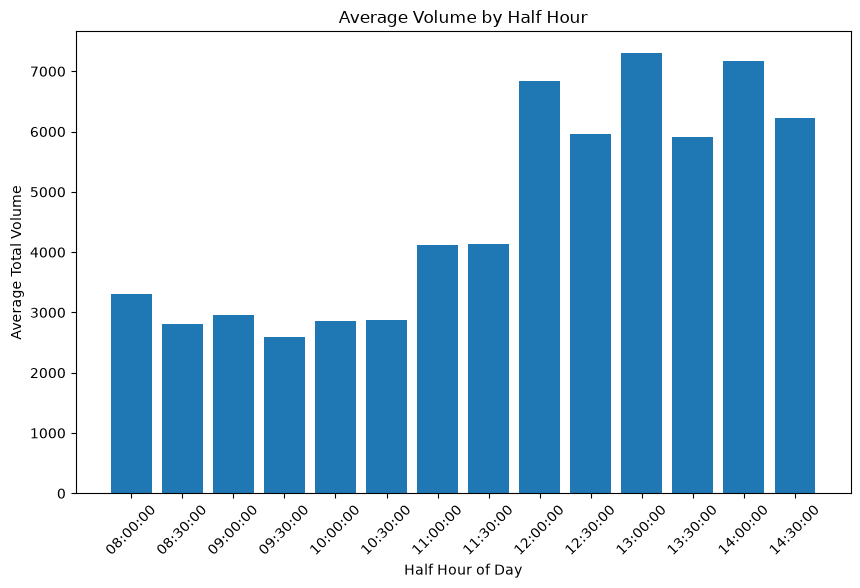

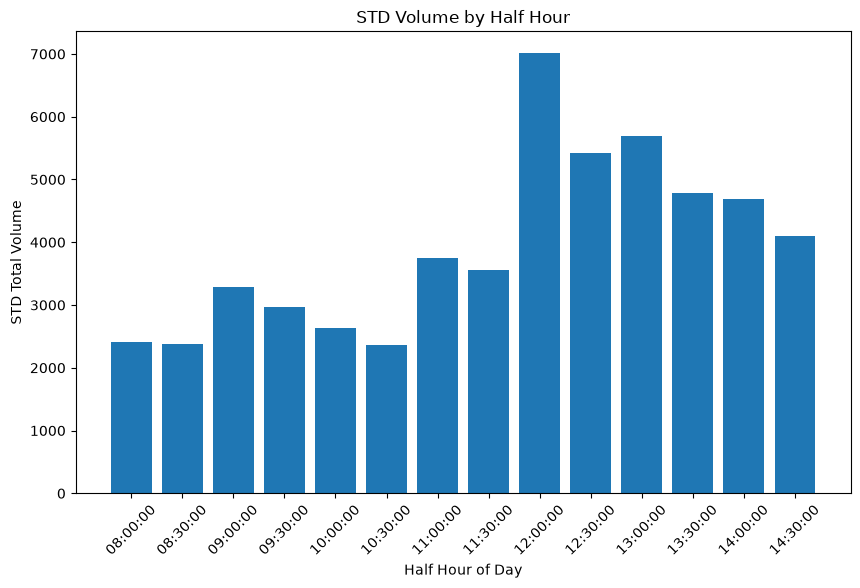

In [22]:
plt.figure(figsize=(10,6))
plt.bar(agg_30.index.astype(str), agg_30['mean'])
plt.xlabel('Half Hour of Day')
plt.ylabel('Average Total Volume')
plt.title('Average Volume by Half Hour')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(10,6))
plt.bar(agg_30.index.astype(str), agg_30['std'])
plt.xlabel('Half Hour of Day')
plt.ylabel('STD Total Volume')
plt.title('STD Volume by Half Hour')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

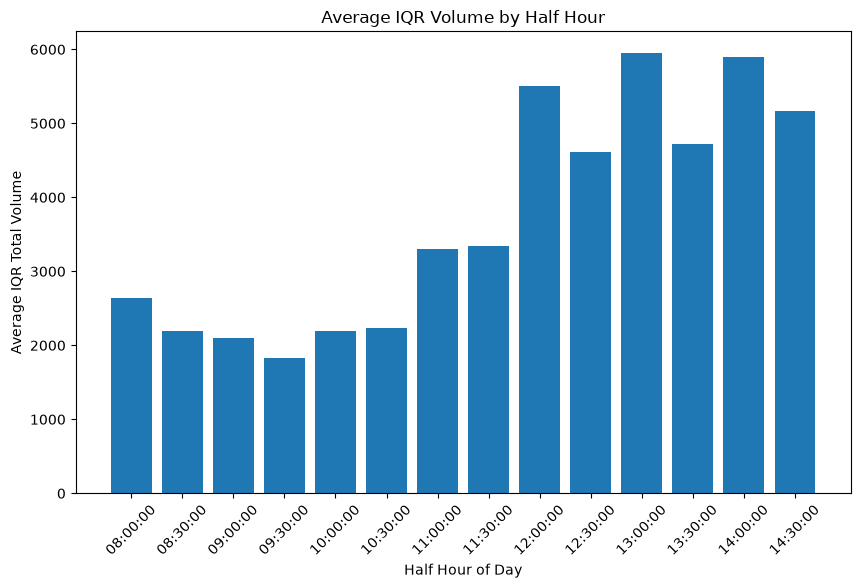

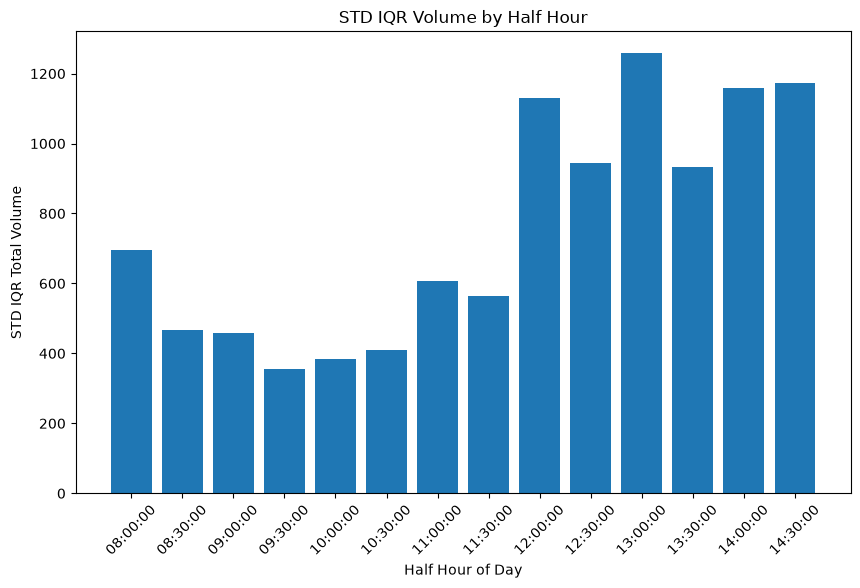

In [26]:
plt.figure(figsize=(10,6))
plt.bar(agg_30_IQR.index.astype(str), agg_30_IQR['mean'])
plt.xlabel('Half Hour of Day')
plt.ylabel('Average IQR Total Volume')
plt.title('Average IQR Volume by Half Hour')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(10,6))
plt.bar(agg_30_IQR.index.astype(str), agg_30_IQR['std'])
plt.xlabel('Half Hour of Day')
plt.ylabel('STD IQR Total Volume')
plt.title('STD IQR Volume by Half Hour')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

Minute Analysis

In [32]:
min_agg = df_min.groupby('bar_time')['volume'].agg(['mean','median','std'])
df_min['q1'] =df_min.groupby('bar_time')['volume'].transform(lambda t: t.quantile(.25))
df_min['q3'] =df_min.groupby('bar_time')['volume'].transform(lambda t: t.quantile(.75))
df_min_IQR = df_min[(df_min['volume']>=df_min['q1'])&(df_min['volume']<=df_min['q3'])]
agg_min_IQR = df_min_IQR.groupby('bar_time')['volume'].agg(['mean','median','std'])

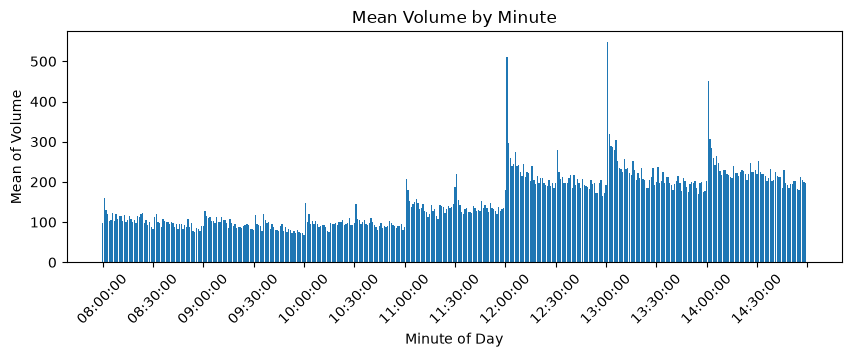

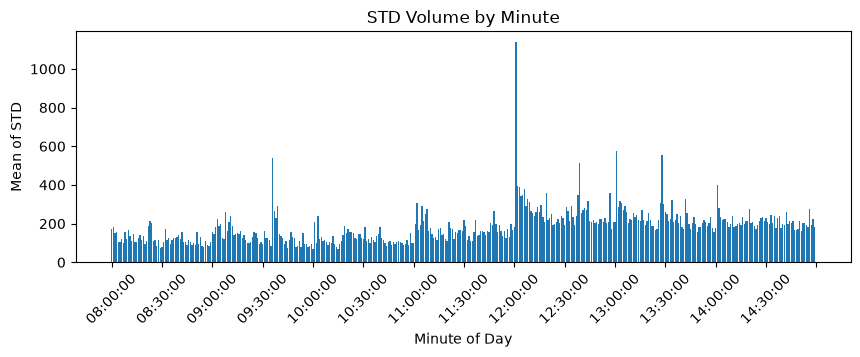

In [46]:
plt.figure(figsize=(10,3))
plt.bar(min_agg.index.astype(str),min_agg['mean'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Minute of Day')
plt.ylabel('Mean of Volume')
plt.title('Mean Volume by Minute')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(10,3))
plt.bar(min_agg.index.astype(str),min_agg['std'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Minute of Day')
plt.ylabel('Mean of STD')
plt.title('STD Volume by Minute')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

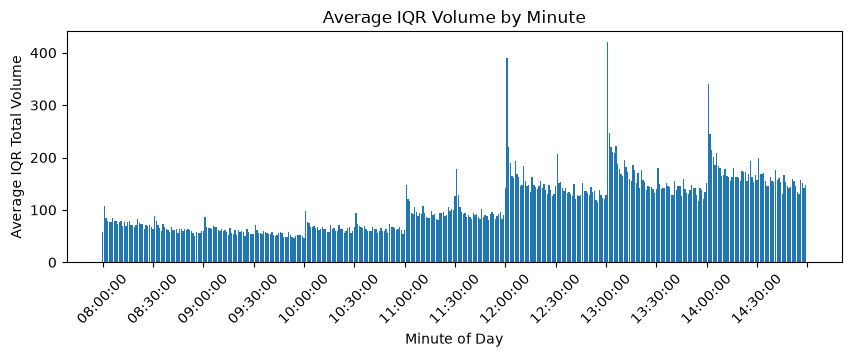

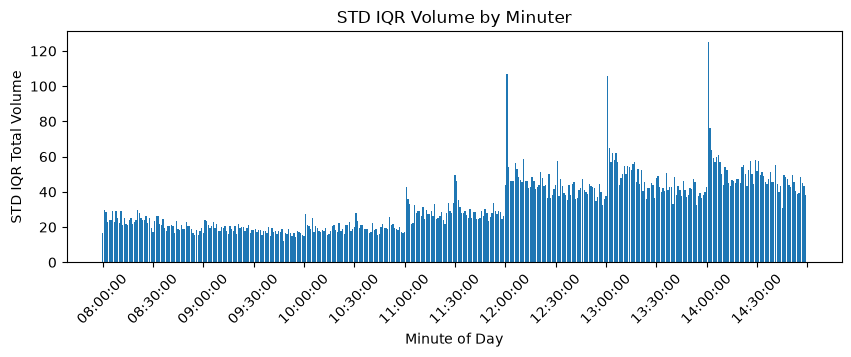

In [47]:
plt.figure(figsize=(10,3))
plt.bar(agg_min_IQR.index.astype(str), agg_min_IQR['mean'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Minute of Day')
plt.ylabel('Average IQR Total Volume')
plt.title('Average IQR Volume by Minute')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(10,3))
plt.bar(agg_min_IQR.index.astype(str), agg_min_IQR['std'])
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(nbins=16))
plt.xlabel('Minute of Day')
plt.ylabel('STD IQR Total Volume')
plt.title('STD IQR Volume by Minuter')

ax = plt.gca()
plt.xticks(rotation=45)

plt.show()